# Baseline Setup

In [1]:
import torch
import matplotlib.pyplot as plt
import types
from sklearn.manifold import TSNE
import copy
from torch import Tensor
import inspect
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

In [30]:
# I am not resizing here rather leaving the resizing to GPU using: inputs = F.interpolate(inputs, size=(224, 224), mode='bilinear', align_corners=False)
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 64

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2, pin_memory=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("CIFAR-10 datasets downloaded and data loaders created.")

CIFAR-10 datasets downloaded and data loaders created.


In [9]:
model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(classes))


params_to_update = []

for name, param in model.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)

optimizer = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:01<00:00, 224MB/s] 


In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)
print("Yay a GPU")

Using device: cuda:0
Yay a GPU


In [14]:
criterion = nn.CrossEntropyLoss()
num_epochs = 3

train_losses_history = []
val_losses_history = []
val_accuracies_history = []

print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    # -- Training --
    model.train()
    running_loss = 0.0
    epoch_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

        if i % 20 == 19:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(trainloader)}], Loss: {running_loss / 20:.3f}')
            running_loss = 0.0

    avg_train_loss = epoch_loss / len(trainloader)
    train_losses_history.append(avg_train_loss)

    # -- Validation --
    model.eval()
    correct = 0
    total = 0
    validation_loss = 0.0

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

            outputs = model(images)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = validation_loss / len(testloader)
    val_accuracy = 100 * correct / total
    val_losses_history.append(avg_val_loss)
    val_accuracies_history.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Val Loss: {avg_val_loss:.3f}, Val Acc: {val_accuracy:.2f}%')

print('Finished Training')

Starting training on cuda:0...
Epoch [1/3], Batch [20/98], Loss: 0.509
Epoch [1/3], Batch [40/98], Loss: 0.509
Epoch [1/3], Batch [60/98], Loss: 0.502
Epoch [1/3], Batch [80/98], Loss: 0.504
Epoch [1/3], Val Loss: 0.518, Val Acc: 82.89%
Epoch [2/3], Batch [20/98], Loss: 0.484
Epoch [2/3], Batch [40/98], Loss: 0.514
Epoch [2/3], Batch [60/98], Loss: 0.497
Epoch [2/3], Batch [80/98], Loss: 0.501
Epoch [2/3], Val Loss: 0.516, Val Acc: 82.84%
Epoch [3/3], Batch [20/98], Loss: 0.498
Epoch [3/3], Batch [40/98], Loss: 0.505
Epoch [3/3], Batch [60/98], Loss: 0.491
Epoch [3/3], Batch [80/98], Loss: 0.490
Epoch [3/3], Val Loss: 0.514, Val Acc: 82.95%
Finished Training


# Residual Connections in Practice

In [15]:
print(inspect.getsource(torchvision.models.resnet.Bottleneck))


class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition" https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion: int = 4

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups
        # Both sel

In [16]:
def no_skip_forward(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)
    out = self.conv3(out)
    out = self.bn3(out)
    out = self.relu(out)
    return out

# Defining this globally to ensure the 'noskip' logic is accessible.

In [17]:
model_noskip = copy.deepcopy(model)
model_noskip.to(device)

model_noskip.layer4[0].forward = types.MethodType(no_skip_forward, model_noskip.layer4[0])
model_noskip.layer4[1].forward = types.MethodType(no_skip_forward, model_noskip.layer4[1])

In [18]:
params_to_update_ns = []

for name, param in model_noskip.named_parameters():
    if param.requires_grad == True:
        params_to_update_ns.append(param)

optimizer_ns = optim.SGD(params_to_update_ns, lr=0.001, momentum=0.9)

In [19]:
criterion = nn.CrossEntropyLoss()
num_epochs = 3

ns_train_losses_history = []
ns_val_losses_history = []
ns_val_accuracies_history = []

print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    # -- Training --
    model_noskip.train()
    running_loss = 0.0
    epoch_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

        optimizer_ns.zero_grad()
        outputs = model_noskip(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ns.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

        if i % 20 == 19:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(trainloader)}], Loss: {running_loss / 20:.3f}')
            running_loss = 0.0

    avg_train_loss = epoch_loss / len(trainloader)
    ns_train_losses_history.append(avg_train_loss)

    # -- Validation --
    model_noskip.eval()
    correct = 0
    total = 0
    validation_loss = 0.0

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

            outputs = model_noskip(images)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = validation_loss / len(testloader)
    val_accuracy = 100 * correct / total
    ns_val_losses_history.append(avg_val_loss)
    ns_val_accuracies_history.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Val Loss: {avg_val_loss:.3f}, Val Acc: {val_accuracy:.2f}%')

print('Finished Training')


Starting training on cuda:0...
Epoch [1/3], Batch [20/98], Loss: 0.956
Epoch [1/3], Batch [40/98], Loss: 0.934
Epoch [1/3], Batch [60/98], Loss: 0.929
Epoch [1/3], Batch [80/98], Loss: 0.917
Epoch [1/3], Val Loss: 0.927, Val Acc: 71.79%
Epoch [2/3], Batch [20/98], Loss: 0.905
Epoch [2/3], Batch [40/98], Loss: 0.897
Epoch [2/3], Batch [60/98], Loss: 0.900
Epoch [2/3], Batch [80/98], Loss: 0.903
Epoch [2/3], Val Loss: 0.904, Val Acc: 72.26%
Epoch [3/3], Batch [20/98], Loss: 0.889
Epoch [3/3], Batch [40/98], Loss: 0.882
Epoch [3/3], Batch [60/98], Loss: 0.890
Epoch [3/3], Batch [80/98], Loss: 0.874
Epoch [3/3], Val Loss: 0.885, Val Acc: 72.80%
Finished Training


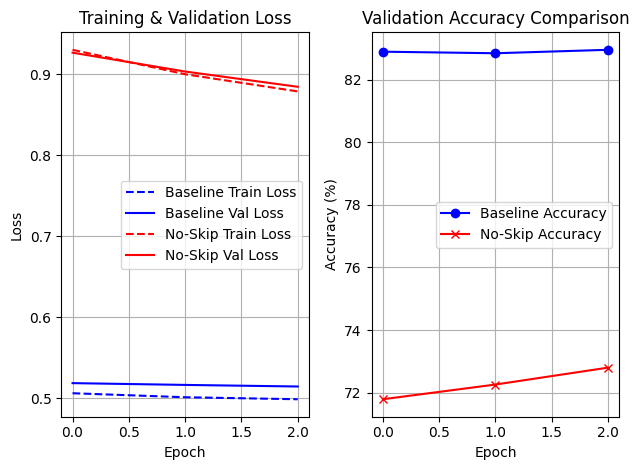

In [20]:
plt.subplot(1, 2, 1)
plt.plot(train_losses_history, label='Baseline Train Loss', color='blue', linestyle='--')
plt.plot(val_losses_history, label='Baseline Val Loss', color='blue')
plt.plot(ns_train_losses_history, label='No-Skip Train Loss', color='red', linestyle='--')
plt.plot(ns_val_losses_history, label='No-Skip Val Loss', color='red')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(val_accuracies_history, label='Baseline Accuracy', color='blue', marker='o')
plt.plot(ns_val_accuracies_history, label='No-Skip Accuracy', color='red', marker='x')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Feature Hierarchies and Representations

In [21]:
feature = {
    'early': [],
    'middle':   [],
    'late':  []
}

labels_list = []

def hook_stage(name):
  def hook_fn(module, input, output):
    pooled = F.adaptive_avg_pool2d(output, (1, 1))
    pooled = pooled.flatten(1)
    feature[name].append(pooled)
  return hook_fn

h1 = model.layer1.register_forward_hook(hook_stage('early'))
h2 = model.layer3.register_forward_hook(hook_stage('middle'))
h3 = model.layer4.register_forward_hook(hook_stage('late'))

model.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
        model(images)
        labels_list.append(labels)

h1.remove()
h2.remove()
h3.remove()


In [22]:
early_features  = torch.cat(feature['early'],  dim=0)
middle_features = torch.cat(feature['middle'], dim=0)
late_features   = torch.cat(feature['late'],   dim=0)
all_labels      = torch.cat(labels_list,         dim=0)

print(early_features.shape)
print(middle_features.shape)
print(late_features.shape)

torch.Size([10000, 256])
torch.Size([10000, 1024])
torch.Size([10000, 2048])


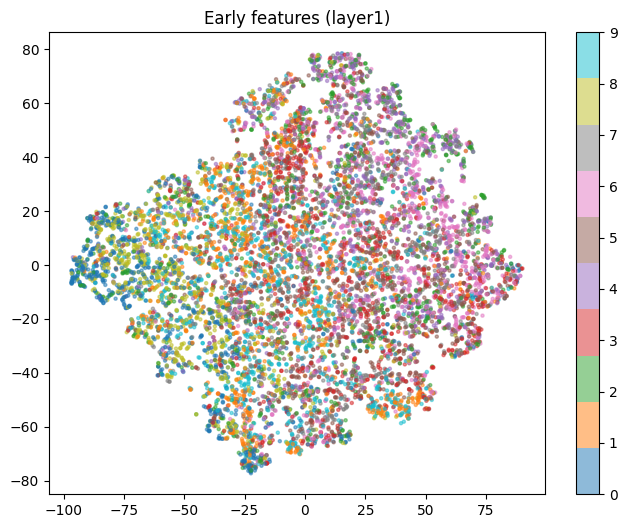

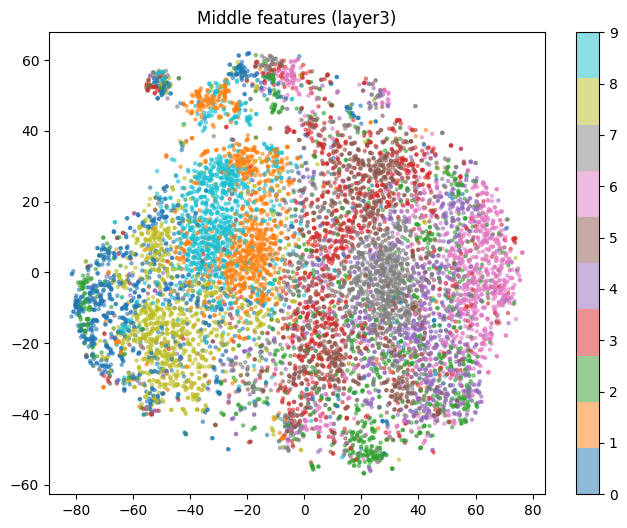

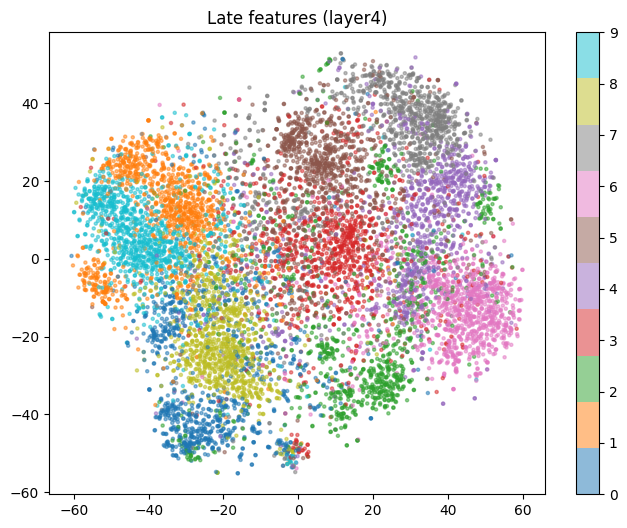

In [23]:
def plot_tsne(features_tensor, labels_tensor, title):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)

    features_cpu = features_tensor.detach().cpu().numpy()
    labels_cpu = labels_tensor.detach().cpu().numpy()

    reduced = tsne.fit_transform(features_cpu)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1],
                          c=labels_cpu, cmap='tab10',
                          alpha=0.5, s=5)
    plt.colorbar(scatter)
    plt.title(title)
    plt.show()


plot_tsne(early_features,  all_labels, 'Early features (layer1)')
plot_tsne(middle_features, all_labels, 'Middle features (layer3)')
plot_tsne(late_features,   all_labels, 'Late features (layer4)')

# Transfer Learning and Generalization

In [24]:
# Our Baseline model fullfills fine-tuning the model on the final head - pre-trained

Fine-tuning head, no pre-trained weights

In [25]:
model_random_head = torchvision.models.resnet152(weights=None)  # no pretrained weights


for param in model_random_head.parameters():
    param.requires_grad = False

num_ftrs = model_random_head.fc.in_features
model_random_head.fc = nn.Linear(num_ftrs, len(classes))

model_random_head = model_random_head.to(device)

optimizer_rh = optim.SGD(model_random_head.fc.parameters(), lr=0.001, momentum=0.9)

In [26]:
criterion = nn.CrossEntropyLoss()
num_epochs = 3

rh_train_losses_history = []
rh_val_losses_history = []
rh_val_accuracies_history = []

print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    # -- Training --
    model_random_head.train()
    running_loss = 0.0
    epoch_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

        optimizer_rh.zero_grad()
        outputs = model_random_head(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_rh.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

        if i % 20 == 19:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(trainloader)}], Loss: {running_loss / 20:.3f}')
            running_loss = 0.0

    avg_train_loss = epoch_loss / len(trainloader)
    rh_train_losses_history.append(avg_train_loss)

    # -- Validation --
    model_random_head.eval()
    correct = 0
    total = 0
    validation_loss = 0.0

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

            outputs = model_random_head(images)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = validation_loss / len(testloader)
    val_accuracy = 100 * correct / total
    rh_val_losses_history.append(avg_val_loss)
    rh_val_accuracies_history.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Val Loss: {avg_val_loss:.3f}, Val Acc: {val_accuracy:.2f}%')

print('Finished Training')

Starting training on cuda:0...
Epoch [1/3], Batch [20/98], Loss: 2.336
Epoch [1/3], Batch [40/98], Loss: 2.293
Epoch [1/3], Batch [60/98], Loss: 2.280
Epoch [1/3], Batch [80/98], Loss: 2.269
Epoch [1/3], Val Loss: 2.277, Val Acc: 13.75%
Epoch [2/3], Batch [20/98], Loss: 2.261
Epoch [2/3], Batch [40/98], Loss: 2.258
Epoch [2/3], Batch [60/98], Loss: 2.256
Epoch [2/3], Batch [80/98], Loss: 2.264
Epoch [2/3], Val Loss: 2.247, Val Acc: 15.89%
Epoch [3/3], Batch [20/98], Loss: 2.250
Epoch [3/3], Batch [40/98], Loss: 2.251
Epoch [3/3], Batch [60/98], Loss: 2.247
Epoch [3/3], Batch [80/98], Loss: 2.248
Epoch [3/3], Val Loss: 2.240, Val Acc: 16.23%
Finished Training


Fine tuning full backbone (Pre-Trained model)

In [32]:
model_pretrained_full = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V1)

for param in model_pretrained_full.parameters():
    param.requires_grad = True

num_ftrs = model_pretrained_full.fc.in_features
model_pretrained_full.fc = nn.Linear(num_ftrs, len(classes))

model_pretrained_full = model_pretrained_full.to(device)

optimizer_pf = optim.SGD(model_pretrained_full.parameters(), lr=0.0001, momentum=0.9)

In [29]:
device = torch.device("cuda:1")

In [33]:
criterion = nn.CrossEntropyLoss()
num_epochs = 3

pf_train_losses_history = []
pf_val_losses_history = []
pf_val_accuracies_history = []

print(f"Starting full fine-tuning on {device}...")

for epoch in range(num_epochs):
    # -- Training --
    model_pretrained_full.train()
    running_loss = 0.0
    epoch_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

        optimizer_pf.zero_grad()
        outputs = model_pretrained_full(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_pf.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

        if i % 200 == 199:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(trainloader)}], Loss: {running_loss / 20:.3f}')
            running_loss = 0.0

    avg_train_loss = epoch_loss / len(trainloader)
    pf_train_losses_history.append(avg_train_loss)

    # -- Validation --
    model_pretrained_full.eval()
    correct = 0
    total = 0
    validation_loss = 0.0

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

            outputs = model_pretrained_full(images)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = validation_loss / len(testloader)
    val_accuracy = 100 * correct / total
    pf_val_losses_history.append(avg_val_loss)
    pf_val_accuracies_history.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Val Loss: {avg_val_loss:.3f}, Val Acc: {val_accuracy:.2f}%')

print('Finished Training Full Model')

Starting full fine-tuning on cuda:1...
Epoch [1/3], Batch [200/782], Loss: 20.394
Epoch [1/3], Batch [400/782], Loss: 13.363
Epoch [1/3], Batch [600/782], Loss: 7.769
Epoch [1/3], Val Loss: 0.421, Val Acc: 90.45%
Epoch [2/3], Batch [200/782], Loss: 3.877
Epoch [2/3], Batch [400/782], Loss: 3.186
Epoch [2/3], Batch [600/782], Loss: 2.790
Epoch [2/3], Val Loss: 0.224, Val Acc: 93.48%
Epoch [3/3], Batch [200/782], Loss: 2.133
Epoch [3/3], Batch [400/782], Loss: 2.013
Epoch [3/3], Batch [600/782], Loss: 1.877
Epoch [3/3], Val Loss: 0.164, Val Acc: 94.94%
Finished Training Full Model


Random init, full backbone fine-tuned

In [6]:
model_random_full = torchvision.models.resnet152(weights=None)


for param in model_random_full.parameters():
    param.requires_grad = True

num_ftrs = model_random_full.fc.in_features
model_random_full.fc = nn.Linear(num_ftrs, len(classes))

model_random_full = model_random_full.to(device)

optimizer_rf = optim.SGD(model_random_full.parameters(), lr=0.001, momentum=0.9)

In [8]:
criterion = nn.CrossEntropyLoss()
num_epochs = 3

rf_train_losses_history = []
rf_val_losses_history = []
rf_val_accuracies_history = []

print(f"Starting training for random full model on {device}...")

for epoch in range(num_epochs):
    # -- Training --
    model_random_full.train()
    running_loss = 0.0
    epoch_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

        optimizer_rf.zero_grad()
        outputs = model_random_full(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_rf.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

        if i % 200 == 199:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(trainloader)}], Loss: {running_loss / 20:.3f}')
            running_loss = 0.0

    avg_train_loss = epoch_loss / len(trainloader)
    rf_train_losses_history.append(avg_train_loss)

    # -- Validation --
    model_random_full.eval()
    correct = 0
    total = 0
    validation_loss = 0.0

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)

            outputs = model_random_full(images)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = validation_loss / len(testloader)
    val_accuracy = 100 * correct / total
    rf_val_losses_history.append(avg_val_loss)
    rf_val_accuracies_history.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Val Loss: {avg_val_loss:.3f}, Val Acc: {val_accuracy:.2f}%')

print('Finished Training Random Full Model')

Starting training for random full model on cuda:0...
Epoch [1/3], Batch [200/782], Loss: 22.748
Epoch [1/3], Batch [400/782], Loss: 20.528
Epoch [1/3], Batch [600/782], Loss: 19.553
Epoch [1/3], Val Loss: 1.832, Val Acc: 31.76%
Epoch [2/3], Batch [200/782], Loss: 17.852
Epoch [2/3], Batch [400/782], Loss: 17.194
Epoch [2/3], Batch [600/782], Loss: 16.639
Epoch [2/3], Val Loss: 1.695, Val Acc: 38.63%
Epoch [3/3], Batch [200/782], Loss: 15.999
Epoch [3/3], Batch [400/782], Loss: 15.762
Epoch [3/3], Batch [600/782], Loss: 15.368
Epoch [3/3], Val Loss: 1.482, Val Acc: 44.76%
Finished Training Random Full Model


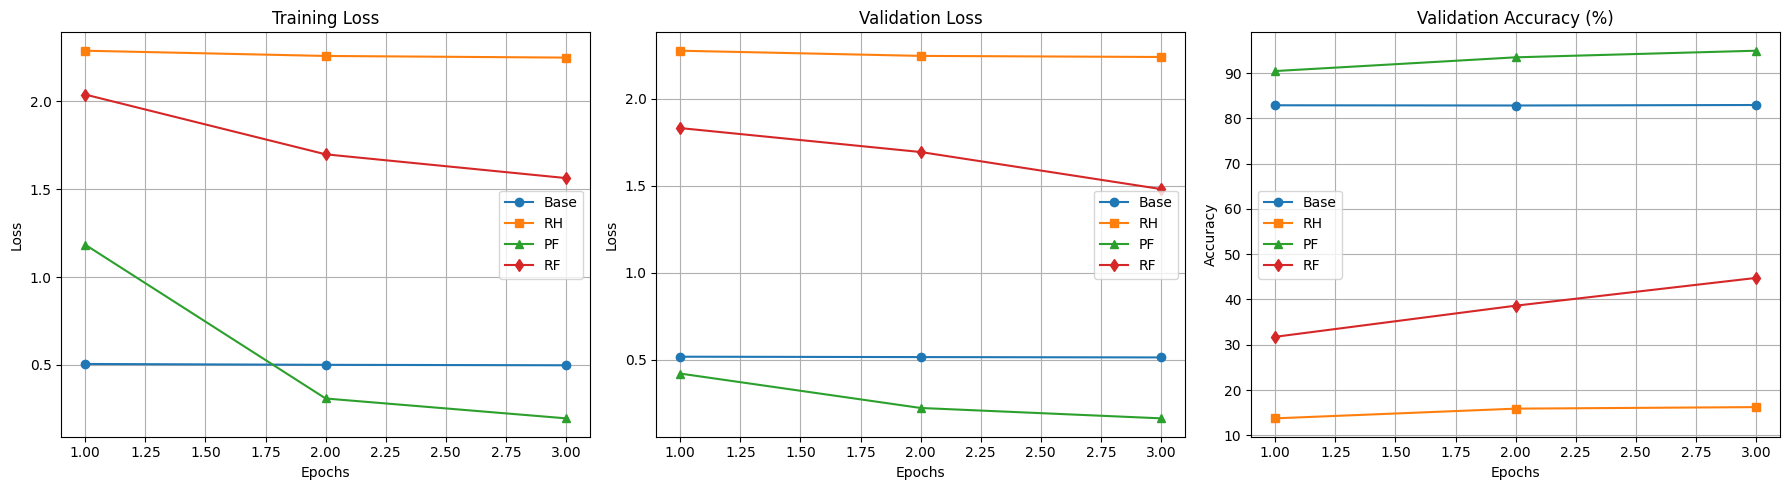

In [35]:
epochs = range(1, 4)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training Losses
ax1.plot(epochs, train_losses_history, label='Base', marker='o')
ax1.plot(epochs, rh_train_losses_history, label='RH', marker='s')
ax1.plot(epochs, pf_train_losses_history, label='PF', marker='^')
ax1.plot(epochs, rf_train_losses_history, label='RF', marker='d')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# 2. Validation Losses
ax2.plot(epochs, val_losses_history, label='Base', marker='o')
ax2.plot(epochs, rh_val_losses_history, label='RH', marker='s')
ax2.plot(epochs, pf_val_losses_history, label='PF', marker='^')
ax2.plot(epochs, rf_val_losses_history, label='RF', marker='d')
ax2.set_title('Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

# 3. Validation Accuracies
ax3.plot(epochs, val_accuracies_history, label='Base', marker='o')
ax3.plot(epochs, rh_val_accuracies_history, label='RH', marker='s')
ax3.plot(epochs, pf_val_accuracies_history, label='PF', marker='^')
ax3.plot(epochs, rf_val_accuracies_history, label='RF', marker='d')
ax3.set_title('Validation Accuracy (%)')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Accuracy')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()